# QC Step 1: SNP Missingness
<u>Input:</u> `.lmiss files` obtained after running the `--missing` command.
<br>
<u>Output:</u> Some plots to see where to set SNP missingness thresholds and also see, how SNPs are spread across individuals from different chips.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Missingness distribution

In [18]:
# Load data
# Define file paths and corresponding chip names
file_paths = {
    'unknown': '../Data/SNPmiss/unknown_chip_SNPmiss.lmiss',
    'HTS_iSelect_HD': '../Data/SNPmiss/HTS_iSelect_HD_SNPmiss.lmiss',
    'Illumina_GSAs': '../Data/SNPmiss/Illumina_GSAs_SNPmiss.lmiss',
    'OmniExpress': '../Data/SNPmiss/OmniExpress_SNPmiss.lmiss',
    'OmniExpress_plus': '../Data/SNPmiss/OmniExpress_plus_SNPmiss.lmiss'
}

/tmp/ipykernel_156736/2023052380.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfs = [pd.read_csv(path, delim_whitespace=True).assign(chip=chip) for chip, path in file_paths.items()]
/tmp/ipykernel_156736/2023052380.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfs = [pd.read_csv(path, delim_whitespace=True).assign(chip=chip) for chip, path in file_paths.items()]
/tmp/ipykernel_156736/2023052380.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfs = [pd.read_csv(path, delim_whitespace=True).assign(chip=chip) for chip, path in file_paths.items()]
/tmp/ipykernel_156736/2023052380.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a 

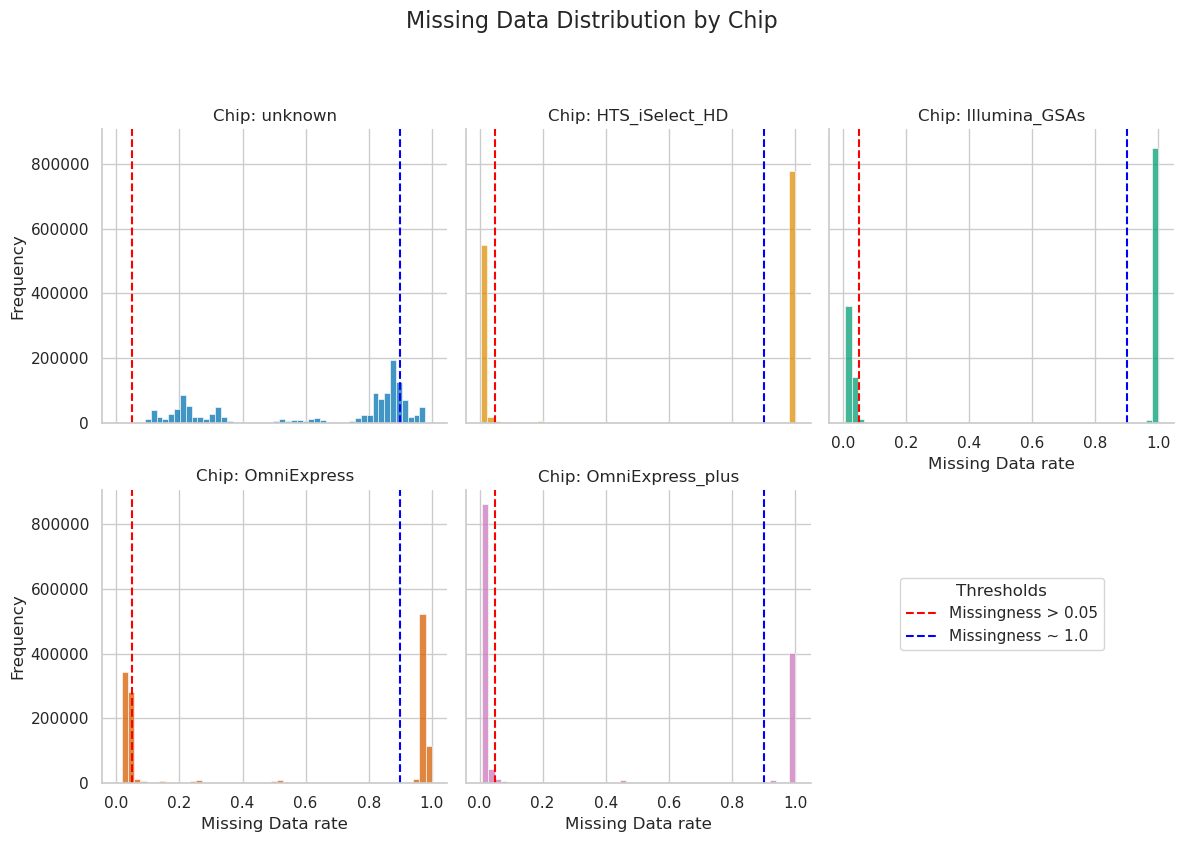

In [25]:
# Load and label each chip's data
dfs = [pd.read_csv(path, delim_whitespace=True).assign(chip=chip) for chip, path in file_paths.items()]
data = pd.concat(dfs, ignore_index=True)

# Color setup
chip_colors = dict(zip(file_paths.keys(), sns.color_palette("colorblind", len(file_paths))))
cutoff_color = 'red'
high_missing_color = 'blue'

# FacetGrid with color per chip
g = sns.FacetGrid(data, col='chip', col_wrap=3, height=4, sharex=True, sharey=True)

# Plot with assigned colors
g.map_dataframe(
    lambda data, color=None, **kwargs: sns.histplot(data, x='F_MISS', bins=50, color=chip_colors[data['chip'].iloc[0]], **kwargs)
)

# Add threshold lines
def draw_lines(*args, **kwargs):
    ax = plt.gca()
    ax.axvline(0.05, color=cutoff_color, linestyle='--')
    ax.axvline(0.9, color=high_missing_color, linestyle='--')

g.map(draw_lines)

# Labels and legend
g.set_axis_labels('Missing Data rate', 'Frequency')
g.set_titles(col_template='Chip: {col_name}')
plt.suptitle('Missing Data Distribution by Chip', y=1.05, fontsize=16)

# Legend
handles = [
    plt.Line2D([0], [0], color=cutoff_color, linestyle='--', label='Missingness > 0.05'),
    plt.Line2D([0], [0], color=high_missing_color, linestyle='--', label='Missingness ~ 1.0')
]
g.fig.legend(handles=handles, loc='upper left', bbox_to_anchor=(0.75, 0.35), title='Thresholds')

plt.tight_layout()
plt.show()